# Project 2: Finding Your Best Neural Network
**Kaleb Coleman**

**MAT499 | March 4, 2026 | Due: 11:59pm Friday March 20th, 2026**

*Submission: iPython Notebook (.ipynb)*

## Setup

In [1]:
import warnings
warnings.filterwarnings('ignore', message='IProgress not found.*')

import numpy as np
import random
import matplotlib.pyplot as plt
import torch

plt.style.use('seaborn-v0_8-whitegrid')

# ── MAT499 Reproducibility Seed ──────────────────────────────────────
SEED = 499  # enrolled class: MAT499

def set_seed(seed=SEED):
    """Set deterministic seeds across all libraries."""
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()
print(f"Reproducibility seed set to {SEED}")
print('Matplotlib style: seaborn-v0_8-whitegrid')

Reproducibility seed set to 499
Matplotlib style: seaborn-v0_8-whitegrid


## Data Loading and Validation

This section loads the Sonar dataset, verifies its shape/classes, and prepares the raw feature and target arrays.

In [2]:
import pandas as pd
import os

# ── Dataset Configuration ────────────────────────────────────────────
# Set LOCAL_CSV_PATH to a local file path if you prefer not to use the remote URL.
# Leave as None to use the course GitHub URL.
LOCAL_CSV_PATH = None  # e.g. "/path/to/local/sonar.csv"

SONAR_REMOTE_URL = (
    "https://raw.githubusercontent.com/benjaminmlucas/MAT499"
    "/refs/heads/main/module_2/sonar.csv"
)

def load_sonar_csv():
    """Load the sonar dataset.
    Tries LOCAL_CSV_PATH first if set, otherwise falls back to remote URL.
    Raises RuntimeError on failure."""
    if LOCAL_CSV_PATH and str(LOCAL_CSV_PATH).lower() != "none":
        path = str(LOCAL_CSV_PATH)
        if not os.path.exists(path):
            raise FileNotFoundError(f"Failed to load Sonar dataset: local file not found at {path}")
        df = pd.read_csv(path)
    else:
        try:
            df = pd.read_csv(SONAR_REMOTE_URL)
        except Exception as exc:
            raise RuntimeError(f"Failed to load Sonar dataset: {exc}") from exc
    return df

df = load_sonar_csv()
print(f"Dataset loaded: {df.shape[0]} rows x {df.shape[1]} columns")

Dataset loaded: 208 rows x 61 columns


In [3]:
# ── Validate Dataset ─────────────────────────────────────────────────
EXPECTED_ROWS    = 208
EXPECTED_COLS    = 61
EXPECTED_CLASSES = 2

assert df.shape == (EXPECTED_ROWS, EXPECTED_COLS), (
    f"Dataset shape mismatch: expected ({EXPECTED_ROWS}, {EXPECTED_COLS}), got {df.shape}"
)
assert df.iloc[:, -1].nunique() == EXPECTED_CLASSES, (
    f"Expected {EXPECTED_CLASSES} classes, got {df.iloc[:, -1].nunique()}"
)

print(f"Shape validated: {df.shape[0]} rows, {df.shape[1]} columns (60 features + 1 label)")
print(f"Classes: {sorted(df.iloc[:, -1].unique())}")
print(f"Class distribution:\n{df.iloc[:, -1].value_counts().to_string()}")

# Separate features and target
X_raw = df.iloc[:, :-1].values.astype(np.float32)
y_raw = df.iloc[:, -1].values

# Encode target: 'M' (Mine) -> 1, 'R' (Rock) -> 0
label_map = {'M': 1, 'R': 0}
y = np.array([label_map.get(lbl, lbl) for lbl in y_raw])

print(f"\nTarget encoded: {np.bincount(y)}  (0=Rock, 1=Mine)")
print(f"Features shape: {X_raw.shape}")

Shape validated: 208 rows, 61 columns (60 features + 1 label)
Classes: ['M', 'R']
Class distribution:
Label
M    111
R     97

Target encoded: [ 97 111]  (0=Rock, 1=Mine)
Features shape: (208, 60)


## Preprocessing

This section defines the fixed 5-fold cross-validation splits and explains the fold-safe scaling procedure used to avoid data leakage.

In [4]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler

# ── Preprocessing Notes ──────────────────────────────────────────────
# StandardScaler is fitted INSIDE each CV fold (on train split only) to prevent data leakage.
# Raw feature arrays are stored here for use in the cross-validation loop.

print(f"Raw features ready for CV preprocessing (scaled per-fold)")
print(f"  X shape: {X_raw.shape},  y shape: {y.shape}")

# ── Cross-Validation Folds (fixed for ALL experiments) ───────────────
N_FOLDS = 5
kf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
fold_indices = list(kf.split(X_raw, y))

print(f"\n{N_FOLDS}-fold StratifiedKFold created (seed={SEED})")
for i, (train_idx, val_idx) in enumerate(fold_indices):
    print(f"  Fold {i+1}: train={len(train_idx)}, val={len(val_idx)}")

Raw features ready for CV preprocessing (scaled per-fold)
  X shape: (208, 60),  y shape: (208,)

5-fold StratifiedKFold created (seed=499)
  Fold 1: train=166, val=42
  Fold 2: train=166, val=42
  Fold 3: train=166, val=42
  Fold 4: train=167, val=41
  Fold 5: train=167, val=41


## Inline Helpers

These helper cells define the reusable model, training loop, and smoke test used by Questions 1-3.

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# ── MLP Architecture ─────────────────────────────────────────────────
class MLP(nn.Module):
    """
    Two-hidden-layer fully connected network.
    architecture: 60 -> hidden1 -> hidden2 -> 1
    dropout_rate: if > 0, applied after each hidden layer.
    """
    def __init__(self, input_dim=60, hidden1=128, hidden2=64, dropout_rate=0.0):
        super().__init__()
        layers = [
            nn.Linear(input_dim, hidden1),
            nn.ReLU(),
        ]
        if dropout_rate > 0:
            layers.append(nn.Dropout(dropout_rate))
        layers += [
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
        ]
        if dropout_rate > 0:
            layers.append(nn.Dropout(dropout_rate))
        layers += [
            nn.Linear(hidden2, 1),
            nn.Sigmoid(),
        ]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

print("MLP class defined: 60 -> 128 -> 64 -> 1  (dropout optional)")

MLP class defined: 60 -> 128 -> 64 -> 1  (dropout optional)


In [6]:
# ── Training Loop ───────────────────────────────────────────────────
def train_model(model, train_loader, val_loader, epochs=200, lr=1e-3, weight_decay=0.0, device='cpu'):
    """
    Train model on train_loader and evaluate on val_loader each epoch.
    Returns dict with per-epoch metrics and the trained model.
    """
    model = model.to(device)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = {'train_loss': [], 'train_error': [], 'val_loss': [], 'val_error': []}

    for epoch in range(epochs):
        # Training
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            output = model(X_batch)
            loss = criterion(output, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * len(y_batch)
            preds = (output > 0.5).float()
            train_correct += (preds == y_batch).sum().item()
            train_total += len(y_batch)
        train_loss /= max(train_total, 1)
        train_error = 1 - train_correct / max(train_total, 1)

        # Validation
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                output = model(X_batch)
                loss = criterion(output, y_batch)
                val_loss += loss.item() * len(y_batch)
                preds = (output > 0.5).float()
                val_correct += (preds == y_batch).sum().item()
                val_total += len(y_batch)
        val_loss /= max(val_total, 1)
        val_error = 1 - val_correct / max(val_total, 1)

        history['train_loss'].append(train_loss)
        history['train_error'].append(train_error)
        history['val_loss'].append(val_loss)
        history['val_error'].append(val_error)

    return history, model

print("train_model function defined")

train_model function defined


In [7]:
# ── Smoke Test ───────────────────────────────────────────────────────
set_seed()
smoke_model = MLP(input_dim=60, hidden1=128, hidden2=64, dropout_rate=0.0)
dummy_input  = torch.randn(8, 60)
dummy_output = smoke_model(dummy_input)
assert dummy_output.shape == (8, 1), f"Expected (8,1), got {dummy_output.shape}"
assert (dummy_output >= 0).all() and (dummy_output <= 1).all()

set_seed()
smoke_drop = MLP(input_dim=60, hidden1=128, hidden2=64, dropout_rate=0.3)
dummy_drop = smoke_drop(dummy_input)
assert dummy_drop.shape == (8, 1)

print(f"Smoke test passed: MLP forward pass OK (batch=8, output in [0,1])")
print(f"  Parameters (no dropout): {sum(p.numel() for p in smoke_model.parameters()):,}")
print(f"  Parameters (dropout=0.3): {sum(p.numel() for p in smoke_drop.parameters()):,}")

Smoke test passed: MLP forward pass OK (batch=8, output in [0,1])
  Parameters (no dropout): 16,129
  Parameters (dropout=0.3): 16,129


## Question 1

We would like to fit a 2-hidden layer fully connected neural network to this data, using 128 neurons and 64 neurons in the hidden layers, respectively. Using 5-fold cross-validation, find the training loss, training error, validation loss, and validation error for this model architecture for each fold. You should train the model for 200 epochs with a mini-batch size of 16. Use the adam optimizer for this learning with the default learning rate.

Create a table that shows the metrics for each fold and their averages.

Comment on the average training loss/error and validation error/loss for this model.

In [8]:
# ── Question 1: Baseline 5-Fold Cross-Validation ───────────────────────────
# Architecture: 60 -> 128 -> 64 -> 1, no dropout, no weight decay
# Training: 200 epochs, batch size 16, Adam optimizer, default LR

HIDDEN1       = 128
HIDDEN2       = 64
EPOCHS        = 200
BATCH_SIZE    = 16
LEARNING_RATE = 1e-3  # Adam default
DROPOUT_RATE  = 0.0   # baseline: no dropout
WEIGHT_DECAY  = 0.0   # baseline: no weight decay

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

q1_results = []
q1_histories = []

for fold_idx, (train_idx, val_idx) in enumerate(fold_indices):
    print(f"\n{'='*55}")
    print(f"  Fold {fold_idx+1}/{N_FOLDS}")
    print(f"{'='*55}")

    # Scale features per-fold (prevent data leakage)
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_raw[train_idx])
    X_val_s   = scaler.transform(X_raw[val_idx])

    # Build DataLoaders
    train_ds = TensorDataset(
        torch.FloatTensor(X_train_s),
        torch.FloatTensor(y[train_idx]).unsqueeze(1)
    )
    val_ds = TensorDataset(
        torch.FloatTensor(X_val_s),
        torch.FloatTensor(y[val_idx]).unsqueeze(1)
    )
    train_ld = DataLoader(
        train_ds, batch_size=BATCH_SIZE, shuffle=True,
        generator=torch.Generator().manual_seed(SEED)
    )
    val_ld = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

    # Train model
    set_seed()
    model = MLP(input_dim=60, hidden1=HIDDEN1, hidden2=HIDDEN2, dropout_rate=DROPOUT_RATE)
    history, _ = train_model(
        model, train_ld, val_ld,
        epochs=EPOCHS, lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY, device=device
    )
    q1_histories.append(history)

    q1_results.append({
        'fold': fold_idx + 1,
        'train_loss': history['train_loss'][-1],
        'train_error': history['train_error'][-1],
        'val_loss':   history['val_loss'][-1],
        'val_error':   history['val_error'][-1],
    })
    print(f"  Final — train_loss={history['train_loss'][-1]:.4f}  "
          f"train_error={history['train_error'][-1]:.4f}  "
          f"val_loss={history['val_loss'][-1]:.4f}  val_error={history['val_error'][-1]:.4f}")

print(f"\n{'='*55}")
print("  Question 1 Baseline Results")
print(f"{'='*55}")
print(f"{'Fold':>4}  {'Train Loss':>12}  {'Train Err':>12}  {'Val Loss':>12}  {'Val Err':>12}")
for r in q1_results:
    print(f"{r['fold']:>4}  {r['train_loss']:>12.6f}  {r['train_error']:>12.6f}  "
          f"{r['val_loss']:>12.6f}  {r['val_error']:>12.6f}")

q1_means = {k: np.mean([r[k] for r in q1_results]) for k in ['train_loss','train_error','val_loss','val_error']}
q1_stds  = {k: np.std( [r[k] for r in q1_results]) for k in ['train_loss','train_error','val_loss','val_error']}
print(f"{'Mean':>4}  {q1_means['train_loss']:>12.6f}  {q1_means['train_error']:>12.6f}  "
      f"{q1_means['val_loss']:>12.6f}  {q1_means['val_error']:>12.6f}")
print(f"{'Std':>4}  {q1_stds['train_loss']:>12.6f}  {q1_stds['train_error']:>12.6f}  "
      f"{q1_stds['val_loss']:>12.6f}  {q1_stds['val_error']:>12.6f}")

def summarize_histories(histories, metric):
    arr = np.array([h[metric] for h in histories], dtype=float)
    return {'mean': arr.mean(axis=0), 'std': arr.std(axis=0)}

q1_curve_summary = {
    'train_loss': summarize_histories(q1_histories, 'train_loss'),
    'val_loss': summarize_histories(q1_histories, 'val_loss'),
    'train_error': summarize_histories(q1_histories, 'train_error'),
    'val_error': summarize_histories(q1_histories, 'val_error'),
}


Using device: cpu

  Fold 1/5
  Final — train_loss=0.0000  train_error=0.0000  val_loss=0.8325  val_error=0.2143

  Fold 2/5
  Final — train_loss=0.0000  train_error=0.0000  val_loss=0.8869  val_error=0.1667

  Fold 3/5
  Final — train_loss=0.0000  train_error=0.0000  val_loss=5.4480  val_error=0.1905

  Fold 4/5
  Final — train_loss=0.0000  train_error=0.0000  val_loss=0.6682  val_error=0.1220

  Fold 5/5
  Final — train_loss=0.0000  train_error=0.0000  val_loss=0.8301  val_error=0.1463

  Question 1 Baseline Results
Fold    Train Loss     Train Err      Val Loss       Val Err
   1      0.000028      0.000000      0.832546      0.214286
   2      0.000028      0.000000      0.886864      0.166667
   3      0.000028      0.000000      5.447969      0.190476
   4      0.000022      0.000000      0.668202      0.121951
   5      0.000023      0.000000      0.830113      0.146341
Mean      0.000026      0.000000      1.733139      0.167944
 Std      0.000003      0.000000      1.858857   

**Q1 Answer:**

The baseline model achieves a **mean training loss of 0.000026** and a **mean training error of 0.000000**, while the **mean validation loss is 1.733139** and the **mean validation error is 0.167944** across the 5 folds.

These results show that the network fits the training data almost perfectly, but its validation performance is noticeably worse. That pattern suggests the model is learning the training set extremely well and may be **overfitting** rather than generalizing cleanly to unseen folds.

The large **standard deviation of validation loss (1.858857)** also shows that performance is somewhat unstable across folds, especially because one fold has a much larger validation loss than the others. So even though the average validation error is reasonable, the baseline model is not especially stable.


### Q1 Curves

The two plots below summarize the average training and validation behavior of the baseline model across the 5 folds. The shaded region represents one standard deviation across folds, which helps show how stable the learning pattern is from split to split.

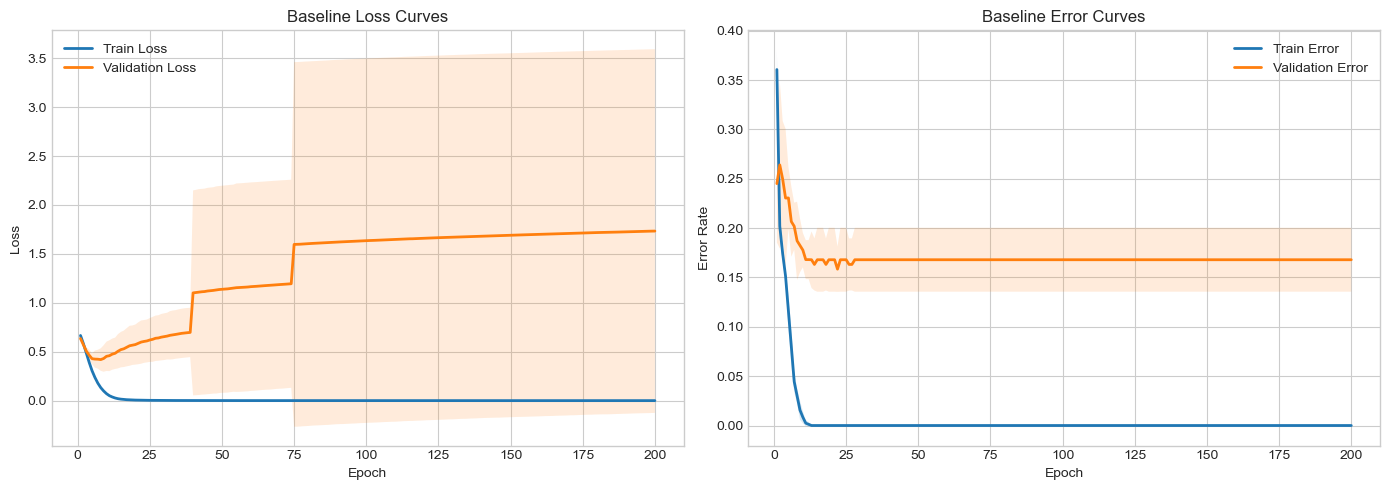

In [9]:
epochs_axis = np.arange(1, len(q1_curve_summary['train_loss']['mean']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_axis, q1_curve_summary['train_loss']['mean'], label='Train Loss', linewidth=2)
axes[0].plot(epochs_axis, q1_curve_summary['val_loss']['mean'], label='Validation Loss', linewidth=2)
axes[0].fill_between(epochs_axis,
                     q1_curve_summary['train_loss']['mean'] - q1_curve_summary['train_loss']['std'],
                     q1_curve_summary['train_loss']['mean'] + q1_curve_summary['train_loss']['std'], alpha=0.15)
axes[0].fill_between(epochs_axis,
                     q1_curve_summary['val_loss']['mean'] - q1_curve_summary['val_loss']['std'],
                     q1_curve_summary['val_loss']['mean'] + q1_curve_summary['val_loss']['std'], alpha=0.15)
axes[0].set_title('Baseline Loss Curves')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(epochs_axis, q1_curve_summary['train_error']['mean'], label='Train Error', linewidth=2)
axes[1].plot(epochs_axis, q1_curve_summary['val_error']['mean'], label='Validation Error', linewidth=2)
axes[1].fill_between(epochs_axis,
                     q1_curve_summary['train_error']['mean'] - q1_curve_summary['train_error']['std'],
                     q1_curve_summary['train_error']['mean'] + q1_curve_summary['train_error']['std'], alpha=0.15)
axes[1].fill_between(epochs_axis,
                     q1_curve_summary['val_error']['mean'] - q1_curve_summary['val_error']['std'],
                     q1_curve_summary['val_error']['mean'] + q1_curve_summary['val_error']['std'], alpha=0.15)
axes[1].set_title('Baseline Error Curves')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Error Rate')
axes[1].legend()

plt.tight_layout()
plt.show()


## Question 2

Now add dropout to the model for regularization with a rate of 0.3. Perform the same 5-fold cross-validation as above and create the same results table. Did dropout improve the model in your educated opinion? Why / why not?

Repeat this process with a weight decay of 0.001 (removing the dropout). Perform the same 5-fold cross-validation as above and create the same results table. Did weight decay improve the model in your educated opinion? Why / why not?

Did dropout or weight decay work better on this model? Why?

In [10]:
# ── Question 2: Regularization Comparison ───────────────────────────────────
# Same 5 folds, same architecture, same epochs/batch/LR.
# Run 1: dropout=0.3, weight_decay=0.0
# Run 2: dropout=0.0, weight_decay=0.001

def run_cv_experiment(dropout_rate, weight_decay, label):
    """Run full 5-fold CV and return results list."""
    print(f"\n  [{label}]")
    results = []
    histories = []
    for fold_idx, (train_idx, val_idx) in enumerate(fold_indices):
        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X_raw[train_idx])
        X_va = scaler.transform(X_raw[val_idx])
        train_ds = TensorDataset(torch.FloatTensor(X_tr), torch.FloatTensor(y[train_idx]).unsqueeze(1))
        val_ds   = TensorDataset(torch.FloatTensor(X_va), torch.FloatTensor(y[val_idx]).unsqueeze(1))
        train_ld = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                             generator=torch.Generator().manual_seed(SEED))
        val_ld   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
        set_seed()
        model = MLP(input_dim=60, hidden1=HIDDEN1, hidden2=HIDDEN2, dropout_rate=dropout_rate)
        history, _ = train_model(
            model, train_ld, val_ld,
            epochs=EPOCHS, lr=LEARNING_RATE, weight_decay=weight_decay, device=device
        )
        histories.append(history)
        results.append({
            'fold': fold_idx+1,
            'train_loss': history['train_loss'][-1],
            'train_error': history['train_error'][-1],
            'val_loss':   history['val_loss'][-1],
            'val_error':   history['val_error'][-1],
        })
        print(f"    Fold {fold_idx+1}: val_loss={history['val_loss'][-1]:.4f}  "
              f"val_error={history['val_error'][-1]:.4f}")
    return results, histories

def print_table(results, label):
    print(f"\n  --- {label} ---")
    print(f"  {'Fold':>4}  {'Train Loss':>12}  {'Train Err':>12}  {'Val Loss':>12}  {'Val Err':>12}")
    for r in results:
        print(f"  {r['fold']:>4}  {r['train_loss']:>12.6f}  {r['train_error']:>12.6f}  "
              f"{r['val_loss']:>12.6f}  {r['val_error']:>12.6f}")
    means = {k: np.mean([r[k] for r in results]) for k in ['train_loss','train_error','val_loss','val_error']}
    stds  = {k: np.std( [r[k] for r in results]) for k in ['train_loss','train_error','val_loss','val_error']}
    print(f"  {'Mean':>4}  {means['train_loss']:>12.6f}  {means['train_error']:>12.6f}  "
          f"{means['val_loss']:>12.6f}  {means['val_error']:>12.6f}")
    print(f"  {'Std':>4}  {stds['train_loss']:>12.6f}  {stds['train_error']:>12.6f}  "
          f"{stds['val_loss']:>12.6f}  {stds['val_error']:>12.6f}")
    return means, stds

q2_dropout_results, q2_dropout_histories = run_cv_experiment(0.3, 0.0, 'Dropout (rate=0.3)')
q2_dropout_mean, q2_dropout_std = print_table(q2_dropout_results, 'Dropout (rate=0.3)')

q2_wd_results, q2_wd_histories = run_cv_experiment(0.0, 0.001, 'Weight Decay (lambda=0.001)')
q2_wd_mean, q2_wd_std = print_table(q2_wd_results, 'Weight Decay (lambda=0.001)')

print(f"\n{'='*55}")
print("  Q2 Summary: Mean Validation Metrics")
print(f"{'='*55}")
print(f"{'Configuration':<35}  {'Val Loss':>10}  {'Val Err':>10}")
print(f"{'Baseline (no reg)':<35}  {q1_means['val_loss']:>10.6f}  {q1_means['val_error']:>10.6f}")
print(f"{'Dropout (0.3)':<35}  {q2_dropout_mean['val_loss']:>10.6f}  {q2_dropout_mean['val_error']:>10.6f}")
print(f"{'Weight Decay (0.001)':<35}  {q2_wd_mean['val_loss']:>10.6f}  {q2_wd_mean['val_error']:>10.6f}")

baseline_ve = q1_means['val_error']
dropout_ve  = q2_dropout_mean['val_error']
wd_ve       = q2_wd_mean['val_error']
best_ve     = min(baseline_ve, dropout_ve, wd_ve)
if best_ve == baseline_ve:   PREFERRED = 'baseline'
elif best_ve == dropout_ve:   PREFERRED = 'dropout'
else:                         PREFERRED = 'weight_decay'

PREFERRED_DROPOUT = 0.3 if PREFERRED == 'dropout' else 0.0
PREFERRED_WD      = 0.001 if PREFERRED == 'weight_decay' else 0.0
print(f"\n  Preferred config: {PREFERRED}  (val_error={best_ve:.4f})")
print(f"  Carrying to Q3: dropout={PREFERRED_DROPOUT}, weight_decay={PREFERRED_WD}")

def build_curve_summary(histories):
    return {
        'train_loss': summarize_histories(histories, 'train_loss'),
        'val_loss': summarize_histories(histories, 'val_loss'),
        'train_error': summarize_histories(histories, 'train_error'),
        'val_error': summarize_histories(histories, 'val_error'),
    }

q2_curve_summaries = {
    'Baseline': q1_curve_summary,
    'Dropout 0.3': build_curve_summary(q2_dropout_histories),
    'Weight Decay 0.001': build_curve_summary(q2_wd_histories),
}



  [Dropout (rate=0.3)]
    Fold 1: val_loss=2.9185  val_error=0.1429
    Fold 2: val_loss=1.8544  val_error=0.2143
    Fold 3: val_loss=5.6899  val_error=0.1905
    Fold 4: val_loss=0.8767  val_error=0.0976
    Fold 5: val_loss=1.2743  val_error=0.1707

  --- Dropout (rate=0.3) ---
  Fold    Train Loss     Train Err      Val Loss       Val Err
     1      0.000118      0.000000      2.918520      0.142857
     2      0.000617      0.000000      1.854398      0.214286
     3      0.000108      0.000000      5.689912      0.190476
     4      0.000160      0.000000      0.876715      0.097561
     5      0.000072      0.000000      1.274250      0.170732
  Mean      0.000215      0.000000      2.522759      0.163182
   Std      0.000203      0.000000      1.726408      0.040331

  [Weight Decay (lambda=0.001)]
    Fold 1: val_loss=0.4384  val_error=0.1429
    Fold 2: val_loss=0.5787  val_error=0.1905
    Fold 3: val_loss=0.7204  val_error=0.1667
    Fold 4: val_loss=0.4079  val_error=0.

**Q2 Answer:**

- **Did dropout improve the model?** Dropout reduced the mean validation error slightly from **0.167944** to **0.163182**, but it increased the mean validation loss from **1.733139** to **2.522759**. In my opinion, dropout did **not clearly improve** the model because the error improvement is small while the loss became noticeably worse.
- **Did weight decay improve the model?** Yes. Weight decay improved both the mean validation loss and the mean validation error. The validation loss dropped to **0.524862** and the validation error dropped to **0.153659**, which is better than both the baseline and dropout models.
- **Which regularizer worked better?** **Weight decay** worked better on this model. It produced the lowest average validation error and the lowest average validation loss, which suggests it gave the best balance between fitting the training data and generalizing across folds.


### Q2 Curves

These plots compare how the baseline, dropout, and weight-decay models behave over training. This makes it easier to see the regularization effect without trying to hide the fact that some overfitting is still present.

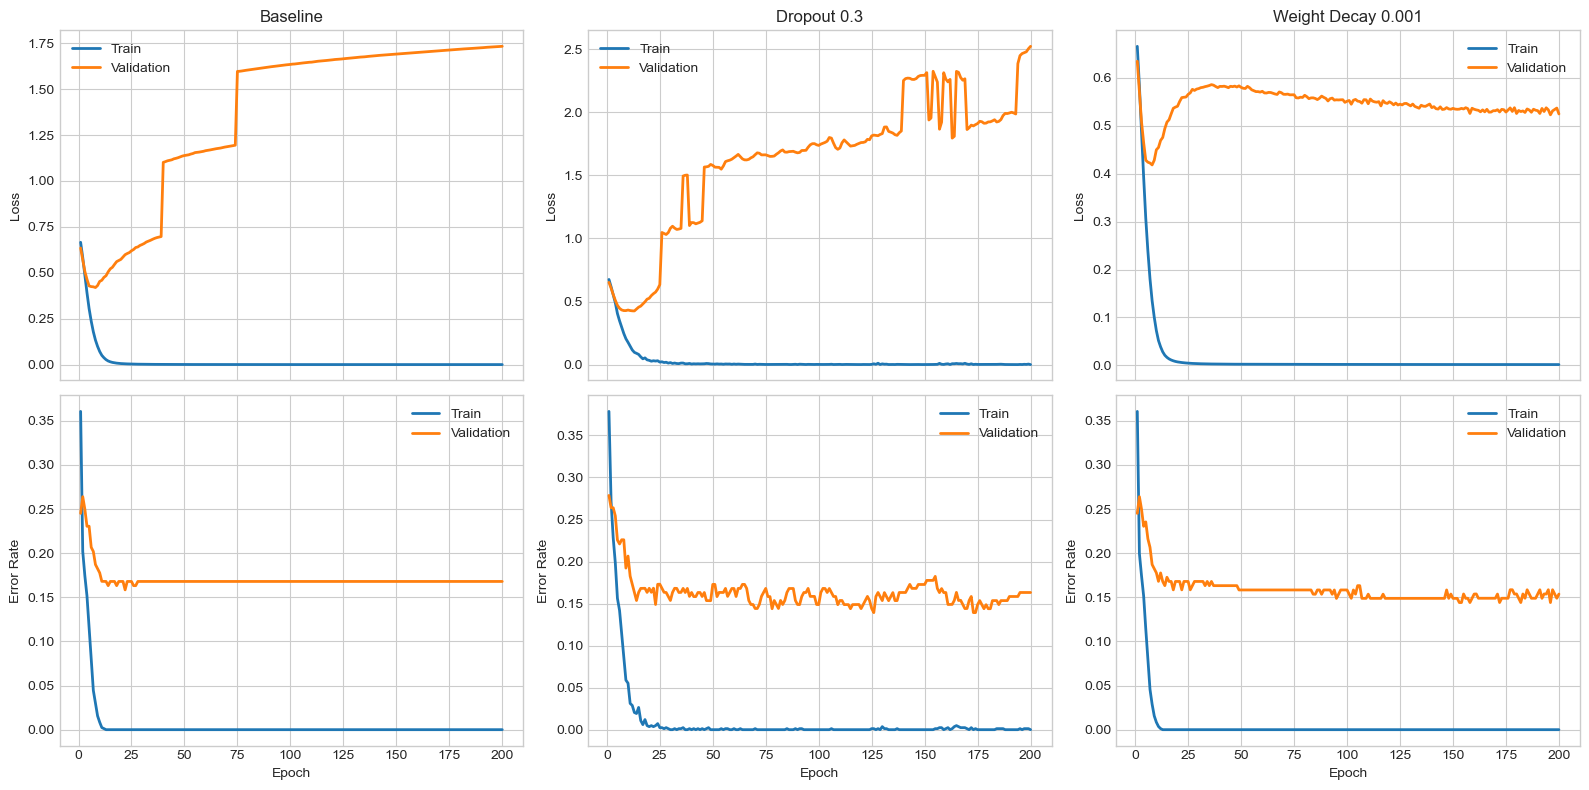

In [11]:
curve_configs = [
    ('Baseline', q2_curve_summaries['Baseline']),
    ('Dropout 0.3', q2_curve_summaries['Dropout 0.3']),
    ('Weight Decay 0.001', q2_curve_summaries['Weight Decay 0.001']),
]
epochs_axis = np.arange(1, len(q2_curve_summaries['Baseline']['train_loss']['mean']) + 1)
fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True)

for col, (title, summary) in enumerate(curve_configs):
    axes[0, col].plot(epochs_axis, summary['train_loss']['mean'], label='Train', linewidth=2)
    axes[0, col].plot(epochs_axis, summary['val_loss']['mean'], label='Validation', linewidth=2)
    axes[0, col].set_title(title)
    axes[0, col].set_ylabel('Loss')
    axes[0, col].legend()

    axes[1, col].plot(epochs_axis, summary['train_error']['mean'], label='Train', linewidth=2)
    axes[1, col].plot(epochs_axis, summary['val_error']['mean'], label='Validation', linewidth=2)
    axes[1, col].set_xlabel('Epoch')
    axes[1, col].set_ylabel('Error Rate')
    axes[1, col].legend()

plt.tight_layout()
plt.show()


## Question 3

Using the preferred model from question 2, experiment with the learning rate. Try at least 5 values and justify which is best for this problem and dataset.

In [12]:
# ── Question 3: Learning Rate Sweep ───────────────────────────────────────────
# Using the preferred configuration from Q2.
# Sweeps 6 learning rates, keeping everything else fixed.

LEARNING_RATES = [1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 5e-3]

print(f"Learning Rate Sweep using: dropout={PREFERRED_DROPOUT}, weight_decay={PREFERRED_WD}")
print(f"{'LR':>10}  {'Mean Val Loss':>14}  {'Std VL':>10}  {'Mean Val Err':>14}  {'Std VE':>10}")

q3_table = []
for lr in LEARNING_RATES:
    fold_vl, fold_ve = [], []
    for fold_idx, (train_idx, val_idx) in enumerate(fold_indices):
        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X_raw[train_idx])
        X_va = scaler.transform(X_raw[val_idx])
        train_ld = DataLoader(
            TensorDataset(torch.FloatTensor(X_tr), torch.FloatTensor(y[train_idx]).unsqueeze(1)),
            batch_size=BATCH_SIZE, shuffle=True,
            generator=torch.Generator().manual_seed(SEED)
        )
        val_ld = DataLoader(
            TensorDataset(torch.FloatTensor(X_va), torch.FloatTensor(y[val_idx]).unsqueeze(1)),
            batch_size=BATCH_SIZE, shuffle=False
        )
        set_seed()
        model = MLP(input_dim=60, hidden1=HIDDEN1, hidden2=HIDDEN2,
                    dropout_rate=PREFERRED_DROPOUT)
        history, _ = train_model(
            model, train_ld, val_ld,
            epochs=EPOCHS, lr=lr, weight_decay=PREFERRED_WD, device=device
        )
        fold_vl.append(history['val_loss'][-1])
        fold_ve.append(history['val_error'][-1])
    mvl, svl = np.mean(fold_vl), np.std(fold_vl)
    mve, sve = np.mean(fold_ve), np.std(fold_ve)
    q3_table.append({'lr': lr, 'mvl': mvl, 'svl': svl, 'mve': mve, 'sve': sve})
    print(f"{lr:>10.0e}  {mvl:>14.6f}  {svl:>10.6f}  {mve:>14.6f}  {sve:>10.6f}")

best_row = min(q3_table, key=lambda r: r['mve'])
BEST_LR = best_row['lr']
print(f"\n  Best learning rate: {BEST_LR:.0e}  (val_error={best_row['mve']:.4f})")

Learning Rate Sweep using: dropout=0.0, weight_decay=0.001
        LR   Mean Val Loss      Std VL    Mean Val Err      Std VE
     1e-05        0.550922    0.021510        0.259350    0.065877
     5e-05        0.434576    0.138175        0.158420    0.022976
     1e-04        0.535513    0.182716        0.163182    0.026403
     5e-04        0.539152    0.138156        0.158304    0.043686
     1e-03        0.524862    0.113485        0.153659    0.044360
     5e-03        0.595627    0.091759        0.158769    0.032833

  Best learning rate: 1e-03  (val_error=0.1537)


**Q3 Answer:**

Using the preferred **weight decay** configuration from Question 2, I tested the learning rates **1e-5, 5e-5, 1e-4, 5e-4, 1e-3, and 5e-3**.

The best learning rate was **1e-3**, which achieved the lowest mean validation error of **0.153659**. This is slightly better than the nearby candidates **5e-5 (0.158420)**, **5e-4 (0.158304)**, and **5e-3 (0.158769)**.

So for this dataset and model, **1e-3 is the best choice** because it gives the strongest average validation performance across all 5 folds while keeping the training stable.


### Q3 Visualization

This visualization shows how the tested learning rates change the mean validation loss and validation error. It gives a clearer picture of why `1e-3` is the best choice for this model and dataset.

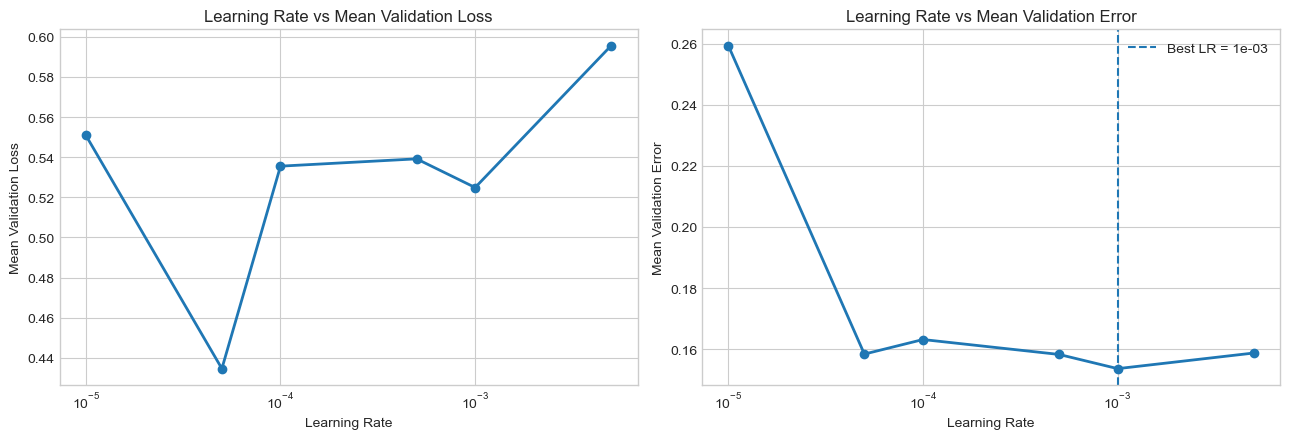

In [13]:
lrs = np.array([row['lr'] for row in q3_table], dtype=float)
val_losses = np.array([row['mvl'] for row in q3_table], dtype=float)
val_errors = np.array([row['mve'] for row in q3_table], dtype=float)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].semilogx(lrs, val_losses, marker='o', linewidth=2)
axes[0].set_title('Learning Rate vs Mean Validation Loss')
axes[0].set_xlabel('Learning Rate')
axes[0].set_ylabel('Mean Validation Loss')

axes[1].semilogx(lrs, val_errors, marker='o', linewidth=2)
axes[1].axvline(BEST_LR, linestyle='--', linewidth=1.5, label=f'Best LR = {BEST_LR:.0e}')
axes[1].set_title('Learning Rate vs Mean Validation Error')
axes[1].set_xlabel('Learning Rate')
axes[1].set_ylabel('Mean Validation Error')
axes[1].legend()

plt.tight_layout()
plt.show()


## Question 4

It is strongly recommended that you use cross-validation to justify all hyperparameter choices on this dataset. Why is this a better approach than a single train-validation split? And why is it specifically more important on this dataset?

*Hint: Look at the Standard Deviation of the validation error across your 5 folds. What does this value tell you about the stability of your model's performance?*

In [14]:
# ── Question 4: Cross-Validation Stability Analysis ───────────────────────────
# Compute fold-to-fold variability to support the Q4 written answer.

def summary_stats(label, val_errs):
    return {
        'label': label,
        'mean': np.mean(val_errs),
        'std':  np.std(val_errs),
        'min':  np.min(val_errs),
        'max':  np.max(val_errs),
    }

baseline_ve = [r['val_error'] for r in q1_results]
dropout_ve  = [r['val_error'] for r in q2_dropout_results]
wd_ve       = [r['val_error'] for r in q2_wd_results]

stats = [
    summary_stats('Baseline',        baseline_ve),
    summary_stats('Dropout 0.3',     dropout_ve),
    summary_stats('Weight Decay 0.001', wd_ve),
]

print("Fold-to-Fold Validation Error Variability")
print(f"\n{'Configuration':<25}  {'Mean VE':>10}  {'Std VE':>10}  {'Min':>8}  {'Max':>8}")
for s in stats:
    print(f"{s['label']:<25}  {s['mean']:>10.4f}  {s['std']:>10.4f}  "
          f"{s['min']:>8.4f}  {s['max']:>8.4f}")

Fold-to-Fold Validation Error Variability

Configuration                 Mean VE      Std VE       Min       Max
Baseline                       0.1679      0.0324    0.1220    0.2143
Dropout 0.3                    0.1632      0.0403    0.0976    0.2143
Weight Decay 0.001             0.1537      0.0444    0.0732    0.1951


**Answer to Question 4**

**Why is cross-validation better than a single train-validation split?**

A single train-validation split uses only one random partitioning of the data, so the final performance estimate depends heavily on that one split. Cross-validation is better because it evaluates the model across multiple splits and then averages the results, producing a more reliable estimate of how the model actually performs.

**Why is this specifically more important for the sonar dataset?**

The sonar dataset is small (**208 samples**) and still has a fairly large number of input features (**60 features**). With a dataset this small, a single split can easily give a misleading result if the training and validation sets happen to be unusually easy or unusually difficult.

The fold-to-fold standard deviations of validation error in this project were:

- **Baseline:** 0.0324
- **Dropout 0.3:** 0.0403
- **Weight Decay 0.001:** 0.0444

These nontrivial standard deviations show that model performance changes across folds, which means the results are not perfectly stable. That is exactly why cross-validation matters here: it captures that variability instead of hiding it behind one possibly lucky or unlucky train-validation split.


## Final Summary

| Metric | Value |
|--------|-------|
| Preferred Regularizer | Weight Decay |
| Dropout Rate | 0.0 |
| Weight Decay | 0.001 |
| Best Learning Rate | 1e-3 |
| Mean Baseline Val Error | 0.167944 |
| Mean Dropout Val Error | 0.163182 |
| Mean Weight-Decay Val Error | 0.153659 |

Overall, the **weight decay** model with **learning rate 1e-3** performed best on this project. It achieved the lowest average validation error and also kept the validation loss much lower than the baseline and dropout versions.


## Reproducibility Appendix

**Dataset:**
- Default source: `https://raw.githubusercontent.com/benjaminmlucas/MAT499/refs/heads/main/module_2/sonar.csv`
- Local override: set `LOCAL_CSV_PATH` in the Data Loading cell to an absolute file path.
- Expected shape: (208, 61) - 60 features + 1 label column.

**Shared folds across experiments:**
- The same fixed `fold_indices` list is reused across Questions 1-3 so the baseline, dropout, weight decay, and learning-rate comparisons are directly comparable.